# Una medición contra los modelos de vórtice

Se elige **una** medición de PIV (lo que guarda **ANALIZAR TODO** en `fluido/data glitter/`) y se
la compara contra los dos modelos de la guía:

| modelo | $v_\theta(r)$ | vorticidad $\omega(r)$ | $v_r(r)$ |
|---|---|---|---|
| **Rankine** | $\Omega r$ si $r<c$; $\ \Omega c^2/r$ si $r\ge c$ | $2\Omega$ adentro, $0$ afuera (un escalón) | $0$ |
| **Burgers** | $\dfrac{\Gamma}{2\pi r}\left(1-e^{-r^2/r_c^2}\right)$ | $\dfrac{\Gamma}{\pi r_c^2}\,e^{-r^2/r_c^2}$ (una gaussiana) | $-\alpha r/2$, con $r_c^2=4\nu/\alpha$ |

**Lamb–Oseen** da exactamente el mismo $v_\theta$ que Burgers (con $r_c^2=4\nu t$ y sin flujo
radial): con el perfil tangencial no se los puede separar.

Todo en mm, s y mm/s. El recipiente es un cilindro y los puntos A y B de la calibración se
marcaron diametralmente opuestos: su radio es `distancia_mm / 2` y su centro, el punto medio de A y B.

Correr las celdas en orden. Lo único para tocar son las variables en MAYÚSCULAS de la sección 1.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.style.use("seaborn-v0_8")
fontsize = 13
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize - 1,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)
AZUL, NARANJA = "#2A6FB5", "#E08A2E"
warnings.filterwarnings("ignore", "Mean of empty slice")   # nodos de la grilla sin ningún vector

DATA = Path("../data glitter")
# Viscosidad cinemática en mm²/s. La glicerina es una mezcla de concentración desconocida:
# ese valor es solo un orden de magnitud.
NU = {"agua": 1.0, "glicerina": 100.0}

# El análisis más nuevo de cada grabación
mediciones = [sorted(g.glob("*/parametros.json"))[-1]
              for g in sorted(DATA.iterdir()) if any(g.glob("*/parametros.json"))]

filas = []
for p in mediciones:
    P = json.loads(p.read_text(encoding="utf-8"))
    cam = P["camaras"]["A"]
    nombre = p.parent.parent.name[18:]          # sin la fecha y la hora de la grabación
    descartados = cam.get("descartados_pct", cam.get("interpolados_pct", np.nan))
    ojo = ("simulación" if "simulacion" in P["grabacion_info"].get("camaras", {}).get("A", {})
           else "arranque, no estacionario" if "DINAMICA" in nombre
           else "descarte alto: sesgada" if descartados > 40 else "")
    filas.append({"grabación": nombre, "rpm": P["grabacion_info"].get("velocidad_agitador_rpm"),
                  "R [mm]": cam["calibracion"]["distancia_mm"] / 2, "pares": cam["pares_analizados"],
                  "descartados [%]": round(descartados, 1), "ojo": ojo})
pd.set_option("display.max_rows", 100)
pd.DataFrame(filas)

,grabación,rpm,R [mm],pares,descartados [%],ojo
0,run3_palangana,1600.0,98.0,58,19.7,
1,barrido_velocidades_palangana_1,800.0,98.0,90,2.1,
2,barrido_velocidades_palangana_2,1000.0,98.0,87,3.4,
3,barrido_velocidades_palangana_3,1200.0,98.0,89,30.0,
4,barrido_velocidades_palangana_4,1400.0,98.0,87,32.3,
5,barrido_velocidades_palangana_5,1600.0,98.0,88,34.3,
6,DINAMICA,1600.0,98.0,572,25.7,"arranque, no estacionario"
7,GLICERINA,1400.0,98.5,87,38.6,
8,GLICERINA_barrido_1,800.0,98.5,89,48.8,descarte alto: sesgada
9,GLICERINA_barrido_2,1000.0,98.5,85,43.1,descarte alto: sesgada


## 1. Elegir la medición

- `CUAL`: el nombre de la grabación, o su número en la tabla de arriba (el nombre es más
  seguro: los números cambian cuando se agregan grabaciones).
- `DESDE_S`, `HASTA_S`: el tramo de la grabación que se usa (`None` = todo). Sirve para las
  grabaciones `DINAMICA`, que son el vórtice arrancando: ahí conviene quedarse con el final.

**Ojo con el descarte.** Cuando más del 40 % de los vectores quedan descartados, los que
sobreviven son los más lentos y el perfil sale sesgado hacia abajo: esa medición no sirve para
ajustar hasta rehacer el análisis en TouchDesigner con `Separación de cuadros = 1`.

**El centro del vórtice** se calcula en cada par con el campo entero: es el punto
$(x_c, y_c)$ respecto del cual el campo es lo más azimutal posible, o sea el que minimiza
$\sum\left[u\,(x-x_c)+v\,(y-y_c)\right]^2$. Es lineal en $(x_c, y_c)$: un sistema de 2×2.

In [10]:
CUAL = "barrido_velocidades_palangana_5"
DESDE_S, HASTA_S = None, None

i = CUAL if isinstance(CUAL, int) else [f["grabación"] for f in filas].index(CUAL)
p = mediciones[i]
P = json.loads(p.read_text(encoding="utf-8"))
cam, info = P["camaras"]["A"], P["grabacion_info"]
cal = cam["calibracion"]
s = cal["mm_por_px"]
NOMBRE = p.parent.parent.name[18:]
RPM = info.get("velocidad_agitador_rpm")
SIM = info.get("camaras", {}).get("A", {}).get("simulacion")      # solo en la simulación
FLUIDO = None if SIM else "glicerina" if "GLICERINA" in NOMBRE.upper() else "agua"
DESCARTADOS = filas[i]["descartados [%]"]

R = cal["distancia_mm"] / 2
centro_recipiente = (np.array(cal["punto_a_px"]) + np.array(cal["punto_b_px"])) / 2 * s

d = pd.read_csv(p.parent / cam["csv"])
if "valido" not in d:                                  # análisis viejos
    d["valido"] = 1 - d["interpolado"]
d.loc[d["valido"] == 0, ["u_mm_s", "v_mm_s"]] = np.nan  # descartado: ahí no se midió nada
d = d[d["t_s"].between(DESDE_S or -np.inf, HASTA_S or np.inf)]

# Un campo por par sobre la grilla: U[par, fila (y), columna (x)]
xs, ys, frames = np.unique(d["x_mm"]), np.unique(d["y_mm"]), np.unique(d["frame"])
X, Y = np.meshgrid(xs, ys)
U = np.full((len(frames), len(ys), len(xs)), np.nan)
V = U.copy()
indice = (np.searchsorted(frames, d["frame"]), np.searchsorted(ys, d["y_mm"]), np.searchsorted(xs, d["x_mm"]))
U[indice], V[indice] = d["u_mm_s"], d["v_mm_s"]
h = xs[1] - xs[0]                                      # separación entre nodos


def centro_del_campo(U, V):
    "Centro de cada par: minimiza sum[u (x - xc) + v (y - yc)]^2 (un sistema de 2x2 por par)."
    medido = np.isfinite(U) & np.isfinite(V)
    u, v = np.where(medido, U, 0), np.where(medido, V, 0)
    uv = u * X + v * Y
    M = np.stack([np.stack([(u * u).sum((1, 2)), (u * v).sum((1, 2))], -1),
                  np.stack([(u * v).sum((1, 2)), (v * v).sum((1, 2))], -1)], -2)
    b = np.stack([(u * uv).sum((1, 2)), (v * uv).sum((1, 2))], -1)
    return np.linalg.solve(M, b[..., None])[..., 0].T


xc, yc = centro_del_campo(U, V)
centro = np.array([np.median(xc), np.median(yc)])

# Polares respecto del centro de CADA par, y la vorticidad derivando el campo 2D
DX, DY = X - xc[:, None, None], Y - yc[:, None, None]
r = np.hypot(DX, DY)
VT = (V * DX - U * DY) / r
VR = (U * DX + V * DY) / r
W = np.gradient(V, xs, axis=2) - np.gradient(U, ys, axis=1)
SENTIDO = np.sign(np.nanmean(VT))                      # +1 antihorario, -1 horario

# Solo anillos completos: el PIV midió dentro de un círculo (la región marcada en TouchDesigner)
# y el vórtice se mueve, así que en cada par se usa hasta donde el anillo entra entero en ese círculo
roi_centro = np.array(cal["centro_vortice_px"]) * s
r_completo = np.minimum(R, cal["radio_roi_px"] * s - np.hypot(xc - roi_centro[0], yc - roi_centro[1]))
dentro = r < r_completo[:, None, None]

t = d.groupby("frame")["t_s"].first()
print(f"medición  : {NOMBRE}  ({'simulación' if SIM else f'{RPM:.0f} rpm, {FLUIDO}'})")
print(f"pares     : {len(frames)}, de t = {t.min():.1f} a {t.max():.1f} s;  "
      f"descartados {DESCARTADOS:.1f} %")
print(f"recipiente: R = {R:.1f} mm;  se analiza hasta r = {np.median(r_completo):.0f} mm")
print(f"centro    : ({centro[0]:.1f}, {centro[1]:.1f}) mm, se mueve ±{np.hypot(xc.std(), yc.std()):.1f} mm "
      f"entre pares; está a {np.hypot(*(centro - centro_recipiente)):.1f} mm del centro del recipiente")
print(f"gira en sentido {'antihorario' if SENTIDO > 0 else 'horario'}"
      + ("" if SENTIDO > 0 else ": se le cambia el signo para que v_θ > 0"))
if DESCARTADOS > 40:
    print(f"\n¡OJO! {DESCARTADOS:.0f} % de vectores descartados: el perfil está sesgado hacia abajo.")
if "DINAMICA" in NOMBRE and DESDE_S is None:
    print("\n¡OJO! es el vórtice arrancando: el promedio mezcla todas las etapas (usar DESDE_S).")

medición  : barrido_velocidades_palangana_5  (1600 rpm, agua)
pares     : 88, de t = 0.0 a 3.0 s;  descartados 34.3 %
recipiente: R = 98.0 mm;  se analiza hasta r = 86 mm
centro    : (194.4, 105.4) mm, se mueve ±4.0 mm entre pares; está a 4.8 mm del centro del recipiente
gira en sentido antihorario


## 2. El campo medido

Promedio de todos los pares en cada nodo. A la izquierda el módulo de la velocidad con las
flechas; a la derecha la vorticidad $\omega=\partial_x v-\partial_y u$ (calculada en cada par y
después promediada). Los puntos rojos son el centro de cada par; el círculo gris, el recipiente
y la cruz, su centro.

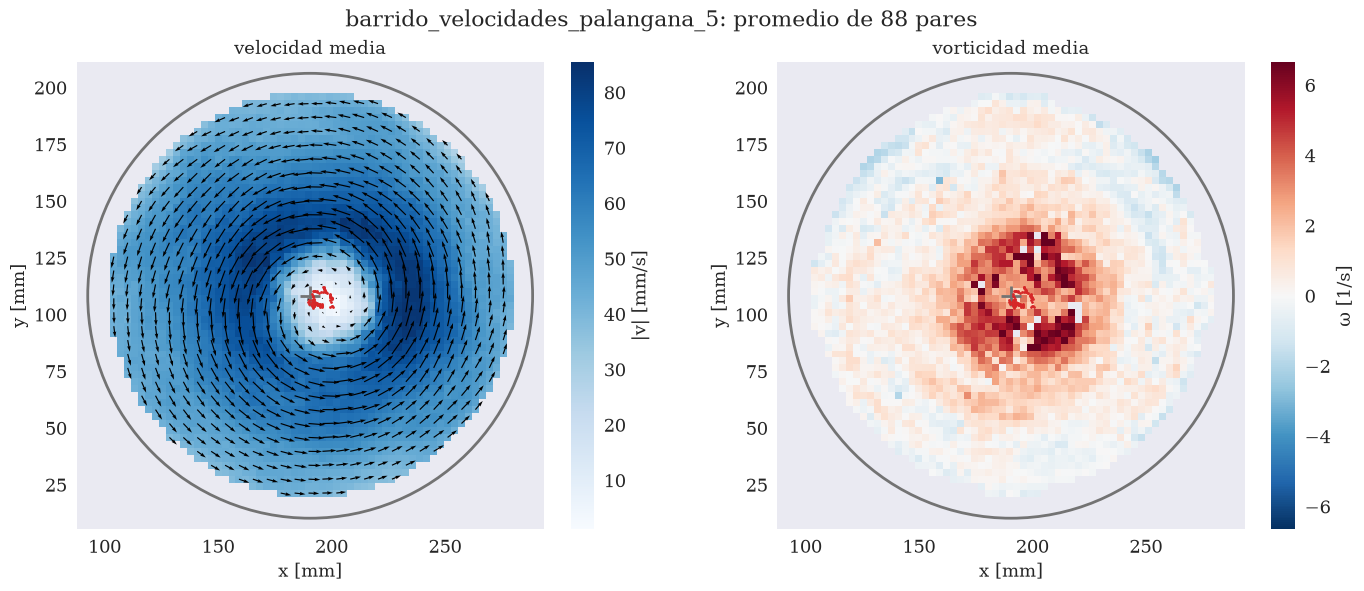

In [11]:
PASO_FLECHAS = 2   # una flecha cada tantos nodos

Um, Vm, Wm = np.nanmean(U, 0), np.nanmean(V, 0), np.nanmean(W, 0)
rapidez = np.hypot(Um, Vm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)
im = ax1.pcolormesh(X, Y, rapidez, cmap="Blues", shading="nearest")
fig.colorbar(im, ax=ax1, label="|v| [mm/s]")
n = PASO_FLECHAS
escala = np.nanpercentile(rapidez, 95) / (1.5 * n * h)          # flecha típica: 1.5 celdas
ax1.quiver(X[::n, ::n], Y[::n, ::n], Um[::n, ::n], Vm[::n, ::n], angles="xy", scale_units="xy",
           scale=escala, width=0.0025, color="k")
ax1.set_title("velocidad media")

lim = np.nanpercentile(np.abs(Wm), 99)
im = ax2.pcolormesh(X, Y, Wm, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="nearest")
fig.colorbar(im, ax=ax2, label=r"$\omega$ [1/s]")
ax2.set_title("vorticidad media")

for ax in (ax1, ax2):
    ax.add_patch(plt.Circle(centro_recipiente, R, fill=False, lw=2, color="0.45"))
    ax.plot(*centro_recipiente, "+", ms=14, mew=2, color="0.45")
    ax.plot(xc, yc, ".", ms=4, color="#D62728")
    ax.set_xlim(centro_recipiente[0] - 1.05 * R, centro_recipiente[0] + 1.05 * R)
    ax.set_ylim(centro_recipiente[1] - 1.05 * R, centro_recipiente[1] + 1.05 * R)
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
fig.suptitle(f"{NOMBRE}: promedio de {len(frames)} pares")
plt.show()

## 3. Velocidad tangencial: ajuste de los dos modelos

El campo se separa en anillos de un nodo de ancho alrededor del centro de cada par, y se
promedia sobre el anillo y sobre todos los pares. La banda es el desvío estándar dentro del
anillo: cuánto se aparta el flujo de un vórtice axisimétrico y estacionario. Es mucho más grande
que el error del promedio, así que los ajustes van sin pesos y se comparan por el **RMS** de los
residuos (en mm/s). Las incertezas de los parámetros salen de la dispersión de esos residuos.

A la derecha, lo mismo en escala logarítmica: afuera del núcleo Rankine y Burgers caen los dos
como $1/r$ (el vórtice potencial) y ahí se ve si el fluido hace lo mismo.

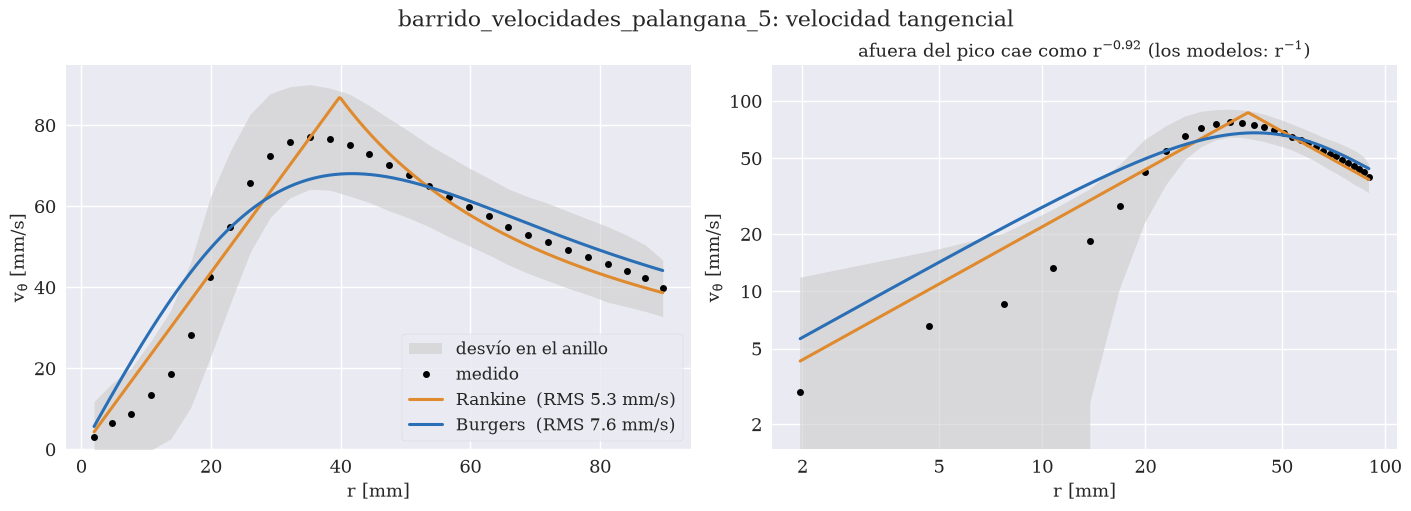

medido : v_θ máxima 77.1 mm/s en r = 35.2 mm
Rankine: Ω = 2.182 ± 0.066 1/s,  c = 39.9 ± 0.8 mm   ->  Γ = 2πΩc² = 21777 mm²/s
Burgers: Γ = 24937 ± 1172 mm²/s,  r_c = 37.2 ± 1.8 mm   ->  su máximo está en 1.12 r_c = 41.7 mm


In [12]:
def rankine(r, Om, c):
    return np.where(r < c, Om * r, Om * c**2 / r)


def burgers(r, G, rc):
    return G / (2 * np.pi * r) * (1 - np.exp(-(r / rc) ** 2))


def w_rankine(r, Om, c):
    return np.where(r < c, 2 * Om, 0.0)


def w_burgers(r, G, rc):
    return G / (np.pi * rc**2) * np.exp(-(r / rc) ** 2)


# Promedio por anillos
anillos = pd.DataFrame({"r": r[dentro], "vt": SENTIDO * VT[dentro], "vr": VR[dentro],
                        "w": SENTIDO * W[dentro]}).groupby(np.floor(r[dentro] / h))
lleno = anillos["vt"].count() >= 20                    # anillos con al menos 20 vectores medidos
media, desvio = anillos.mean()[lleno], anillos.std()[lleno]
rr, vt = media["r"].to_numpy(), media["vt"].to_numpy()

# Ajustes, arrancando del pico medido
k = np.argmax(vt)
r_pico, v_pico = rr[k], vt[k]
ajustes = {}
for nombre, f, w, p0 in (("Rankine", rankine, w_rankine, [v_pico / r_pico, r_pico]),
                         ("Burgers", burgers, w_burgers, [2 * np.pi * r_pico * v_pico / 0.715, r_pico / 1.12])):
    pars, cov = curve_fit(f, rr, vt, p0=p0)
    ajustes[nombre] = dict(f=f, w=w, pars=pars, err=np.sqrt(np.diag(cov)),
                           rms=np.sqrt(np.mean((f(rr, *pars) - vt) ** 2)))
COLOR = {"Rankine": NARANJA, "Burgers": AZUL}

# Cómo cae afuera: v ~ r^-n entre 1.5 veces el pico y el borde
afuera = (rr > 1.5 * r_pico) & (vt > 0)
n_caida = -np.polyfit(np.log(rr[afuera]), np.log(vt[afuera]), 1)[0] if afuera.sum() >= 3 else np.nan

r_fino = np.linspace(rr.min(), rr.max(), 400)
fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax in axs:
    ax.fill_between(rr, vt - desvio["vt"], vt + desvio["vt"], color="0.8", alpha=0.6, lw=0,
                    label="desvío en el anillo")
    ax.plot(rr, vt, "o", ms=5, color="k", label="medido")
    for nombre, a in ajustes.items():
        ax.plot(r_fino, a["f"](r_fino, *a["pars"]), lw=2.2, color=COLOR[nombre],
                label=f"{nombre}  (RMS {a['rms']:.1f} mm/s)")
    ax.set_xlabel("r [mm]")
    ax.set_ylabel(r"$v_\theta$ [mm/s]")
if SIM:   # la simulación: el vórtice que se inyectó
    for ax in axs:
        ax.plot(r_fino, rankine(r_fino, SIM["omega_nucleo_rad_s"], SIM["radio_nucleo_px"] * s),
                "--", lw=1.5, color="0.3", label="inyectado")
axs[0].set_ylim(bottom=0)
axs[0].legend()
axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_ylim(0.5 * vt[vt > 0].min(), 2 * vt.max())
for eje in (axs[1].xaxis, axs[1].yaxis):
    eje.set_major_locator(plt.LogLocator(subs=(1, 2, 5)))
    eje.set_major_formatter(plt.FormatStrFormatter("%g"))
    eje.set_minor_formatter(plt.NullFormatter())
axs[1].set_title(f"afuera del pico cae como $r^{{-{n_caida:.2f}}}$ (los modelos: $r^{{-1}}$)"
                 if np.isfinite(n_caida) else "el pico está muy afuera: no hay tramo exterior")
fig.suptitle(f"{NOMBRE}: velocidad tangencial")
plt.show()

Om, c = ajustes["Rankine"]["pars"]
eOm, ec = ajustes["Rankine"]["err"]
G, rc = ajustes["Burgers"]["pars"]
eG, erc = ajustes["Burgers"]["err"]
print(f"medido : v_θ máxima {v_pico:.1f} mm/s en r = {r_pico:.1f} mm")
print(f"Rankine: Ω = {Om:.3f} ± {eOm:.3f} 1/s,  c = {c:.1f} ± {ec:.1f} mm   ->  Γ = 2πΩc² = {2 * np.pi * Om * c**2:.0f} mm²/s")
print(f"Burgers: Γ = {G:.0f} ± {eG:.0f} mm²/s,  r_c = {rc:.1f} ± {erc:.1f} mm   ->  "
      f"su máximo está en 1.12 r_c = {1.121 * rc:.1f} mm")

## 4. Vorticidad: el juez más duro

$v_\theta(r)$ es una curva suave y los dos modelos la siguen parecido. La vorticidad es una
derivada, y ahí los modelos son muy distintos: un escalón (Rankine) contra una gaussiana
(Burgers). Las curvas **no se reajustan**: salen de los parámetros de la sección 3, y se comparan
con la vorticidad medida (la derivada del campo 2D, promediada por anillos).

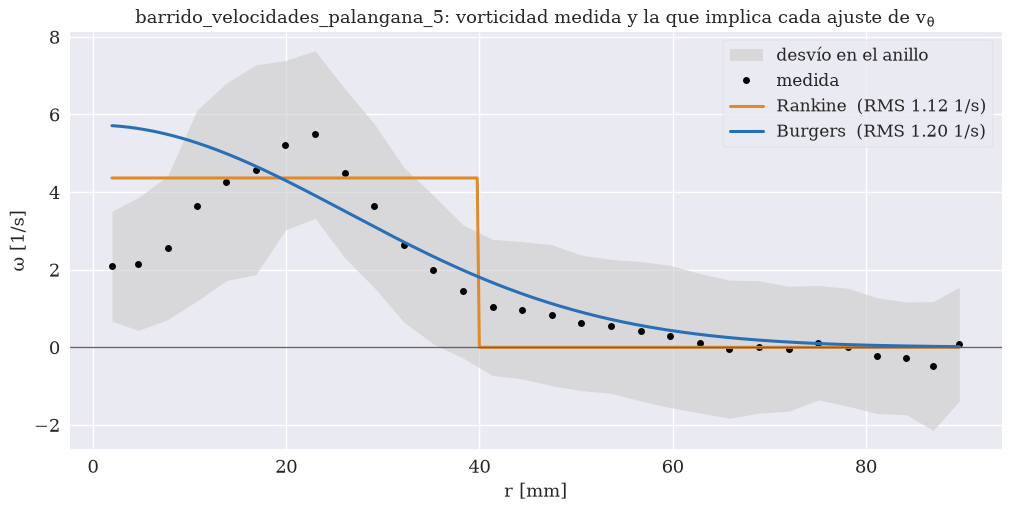

In [13]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
w_med = media["w"].to_numpy()
ax.fill_between(rr, w_med - desvio["w"], w_med + desvio["w"], color="0.8", alpha=0.6, lw=0,
                label="desvío en el anillo")
ax.plot(rr, w_med, "o", ms=5, color="k", label="medida")
for nombre, a in ajustes.items():
    a["rms_w"] = np.sqrt(np.nanmean((a["w"](rr, *a["pars"]) - w_med) ** 2))
    ax.plot(r_fino, a["w"](r_fino, *a["pars"]), lw=2.2, color=COLOR[nombre],
            label=f"{nombre}  (RMS {a['rms_w']:.2f} 1/s)")
ax.axhline(0, color="0.4", lw=1)
ax.set_xlabel("r [mm]")
ax.set_ylabel(r"$\omega$ [1/s]")
ax.legend()
ax.set_title(f"{NOMBRE}: vorticidad medida y la que implica cada ajuste de $v_\\theta$")
plt.show()

## 5. Velocidad radial: lo que agrega Burgers

Rankine no tiene flujo radial. Burgers sí: $v_r=-\alpha r/2$, hacia el eje, y ese mismo
$\alpha$ fija el núcleo, $r_c^2=4\nu/\alpha$. Se ajusta una recta por el origen a $v_r(r)$ y con
el $\alpha$ que sale se prueba si el núcleo medido es compatible con la viscosidad del fluido.

El glitter flota, así que lo medido es la **superficie**. Ahí la recirculación del recipiente
(el fondo empuja el fluido hacia el eje, sube por el centro y vuelve hacia afuera por arriba)
puede dar $v_r>0$, el signo opuesto al de Burgers.

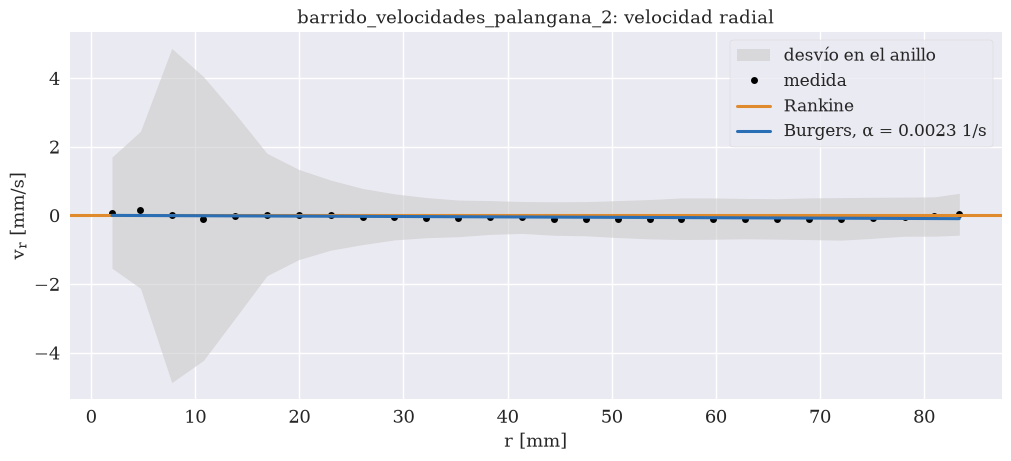

α = 0.0023 ± 0.0004 1/s;  |v_r| media = 0.07 mm/s, el 0.3 % de la v_θ máxima
-> flujo hacia el eje, como Burgers
con ν del agua (1 mm²/s), Burgers pide un núcleo r_c = √(4ν/α) = 41.4 mm; el ajustado es 12.3 mm
para que cierre haría falta ν = α r_c²/4 = 0.0882 mm²/s


In [9]:
vr = media["vr"].to_numpy()
alfa = -2 * np.sum(rr * vr) / np.sum(rr**2)            # recta por el origen: v_r = -alfa r / 2
e_alfa = 2 * np.sqrt(np.sum((vr + alfa * rr / 2) ** 2) / (len(rr) - 1) / np.sum(rr**2))

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
ax.fill_between(rr, vr - desvio["vr"], vr + desvio["vr"], color="0.8", alpha=0.6, lw=0,
                label="desvío en el anillo")
ax.plot(rr, vr, "o", ms=5, color="k", label="medida")
ax.axhline(0, color=NARANJA, lw=2.2, label="Rankine")
ax.plot(r_fino, -alfa * r_fino / 2, lw=2.2, color=AZUL, label=rf"Burgers, $\alpha$ = {alfa:.2g} 1/s")
ax.set_xlabel("r [mm]")
ax.set_ylabel(r"$v_r$ [mm/s]")
ax.legend()
ax.set_title(f"{NOMBRE}: velocidad radial")
plt.show()

print(f"α = {alfa:.4f} ± {e_alfa:.4f} 1/s;  |v_r| media = {np.mean(np.abs(vr)):.2f} mm/s, "
      f"el {100 * np.mean(np.abs(vr)) / v_pico:.1f} % de la v_θ máxima")
if abs(alfa) < 2 * e_alfa:
    print("-> v_r compatible con cero: como Rankine (y Lamb–Oseen); Burgers necesita α > 0")
elif alfa < 0:
    print("-> flujo hacia afuera: al revés que Burgers")
else:
    print("-> flujo hacia el eje, como Burgers")
if alfa > 2 * e_alfa and FLUIDO:
    print(f"con ν del {FLUIDO} ({NU[FLUIDO]:g} mm²/s), Burgers pide un núcleo r_c = √(4ν/α) = "
          f"{np.sqrt(4 * NU[FLUIDO] / alfa):.1f} mm; el ajustado es {rc:.1f} mm")
    print(f"para que cierre haría falta ν = α r_c²/4 = {alfa * rc**2 / 4:.3g} mm²/s")

## 6. Resumen

Los dos modelos lado a lado. $\Gamma$ es la circulación total y $\omega(0)$ la vorticidad en el
eje; en Rankine $\Gamma=2\pi\Omega c^2$ y $\omega(0)=2\Omega$, en Burgers
$\omega(0)=\Gamma/(\pi r_c^2)$. El radio del núcleo es $c$ en Rankine y $r_c$ en Burgers (que tiene
su máximo de $v_\theta$ en $1.12\,r_c$). Para la simulación se agrega el vórtice que se inyectó.

**Para calibrar el ojo**, correr todo con `CUAL = "particula_prueba"`: es la simulación, con un
vórtice de Rankine conocido. El método recupera bien el radio del núcleo y la caída $1/r$, pero el
PIV redondea la punta (las ventanas miden unos 6 mm) y ahí Burgers ajusta casi tan bien como
Rankine. Una diferencia chica de RMS en $v_\theta$ no alcanza para elegir modelo: miran más fino
la vorticidad y en qué parte del perfil falla cada uno.

In [11]:
resumen = pd.DataFrame({
    "Rankine": {"Γ [mm²/s]": 2 * np.pi * Om * c**2, "núcleo [mm]": c, "ω(0) [1/s]": 2 * Om,
                "RMS v_θ [mm/s]": ajustes["Rankine"]["rms"], "RMS ω [1/s]": ajustes["Rankine"]["rms_w"]},
    "Burgers": {"Γ [mm²/s]": G, "núcleo [mm]": rc, "ω(0) [1/s]": G / (np.pi * rc**2),
                "RMS v_θ [mm/s]": ajustes["Burgers"]["rms"], "RMS ω [1/s]": ajustes["Burgers"]["rms_w"]},
}).T
if SIM:
    Om_sim, c_sim = SIM["omega_nucleo_rad_s"], SIM["radio_nucleo_px"] * s
    resumen.loc["inyectado (Rankine)"] = [2 * np.pi * Om_sim * c_sim**2, c_sim, 2 * Om_sim, np.nan, np.nan]
print(f"{NOMBRE}" + ("" if SIM else f"  ({RPM:.0f} rpm, {FLUIDO}, R = {R:.0f} mm)"))
resumen.round(2)

barrido_velocidades_palangana_4  (1400 rpm, agua, R = 98 mm)


,Γ [mm²/s],núcleo [mm],ω(0) [1/s],RMS v_θ [mm/s],RMS ω [1/s]
Rankine,11126.53,36.69,2.63,2.53,0.65
Burgers,12472.80,33.52,3.53,3.47,0.77
